In [1]:
#  Imports & Mount
from google.colab import drive
drive.mount("/content/drive")

import pandas as pd
import numpy as np
import ast
import re
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict

BASE = "/content/drive/MyDrive/nlp/final project/"

Mounted at /content/drive


In [9]:
df_merged = pd.read_csv(BASE + "articles_merged_full.csv")

df_merged.head()

,url,date_x,title,clean_text,text_len,domain,text_bt,topic_id,ner_text,orgs_raw,orgs,tech_terms,industry,sentiment,sentiment_compound,neg_score,neu_score,pos_score,date_y
0,https://www.fox35orlando.com/news/wendys-addin...,2023-05-10,Wendy's adding Google Cloud AI tech to drive-t...,Wendy's adding Google Cloud AI tech to drive-t...,7127,www.fox35orlando.com,Wendy's adding Google Cloud AI tech to drive-t...,86,Wendy's adding Google Cloud AI tech to drive-t...,"['Wendy', 'LiveNewsWeatherGood Day']","['Wendy', 'LiveNewsWeatherGood Day']",[],Other / Mixed,neutral,0.000284,0.000275,0.999166,0.000559,2023-05-10
1,https://citylife.capetown/ps/uncategorized/has...,2023-12-12,ایا چا د AI سره واده کړی؟,ایا چا د AI سره واده کړی؟ نورو وېبپاڼو ته لارس...,4882,citylife.capetown,ایا چا د AI سره واده کړی؟ نورو وېبپاڼو ته لارس...,13,ایا چا د AI سره واده کړی؟. ایا چا د AI سره واد...,"['ایا چا د AI', 'کال د دسمبر', 'ژوندد نوي ټیکن...","['ایا چا د AI', 'کال د دسمبر', 'ژوندد نوي ټیکن...",[],AI Chips & Financial Markets,neutral,0.003190,0.003292,0.990226,0.006482,2023-12-12
2,https://timesofindia.indiatimes.com/technology...,2025-08-27,Anthropic settles copyright lawsuit with US au...,Anthropic settles copyright lawsuit with US au...,12231,timesofindia.indiatimes.com,Anthropic settles copyright lawsuit with US au...,51,Anthropic settles copyright lawsuit with US au...,['The Times of India'],['The Times of India'],[],OpenAI & Big Tech,neutral,0.000078,0.000565,0.998793,0.000643,2025-08-27
3,https://www.lokmattimes.com/entertainment/need...,2025-02-06,'Need to be bit more safe and careful with int...,'Need to be bit more safe and careful with int...,6215,www.lokmattimes.com,'Need to be bit more safe and careful with int...,7,'Need to be bit more safe and careful with int...,"['AI - www.lokmattimes.comCityMarathi', 'Viral...","['AI - www.lokmattimes.comCityMarathi', 'Viral...",['gpu'],Other / Mixed,neutral,0.003351,0.000650,0.995349,0.004001,2025-02-06
4,http://en.people.cn/n3/2022/0920/c90000-101494...,2022-09-20,Scientists using AI to see how COVID-19 might ...,Scientists using AI to see how COVID-19 might ...,3057,en.people.cn,Scientists using AI to see how COVID-19 might ...,4,Scientists using AI to see how COVID-19 might ...,[],[],[],Healthcare & Clinical AI,neutral,0.000186,0.000296,0.999221,0.000482,2022-09-20


Articles after removing noise industries: 7259
                              industry  article_count  mean_compound  pct_positive  pct_neutral  pct_negative
              Healthcare & Clinical AI            885       0.089964     10.395480    88.135593      1.468927
          AI Chips & Financial Markets           1425       0.075854     10.245614    87.157895      2.596491
               Cybersecurity & AI Risk            149       0.063688      9.395973    88.590604      2.013423
                  Finance & Investment            430       0.054713      8.837209    87.441860      3.720930
        Generative AI & Creative Tools           2505       0.048686      6.307385    92.175649      1.516966
Enterprise IT & Digital Transformation            450       0.041695      4.888889    94.000000      1.111111
                     OpenAI & Big Tech            793       0.036688      5.548550    92.307692      2.143758
               ChatGPT & AI Assistants            622       0.033860     

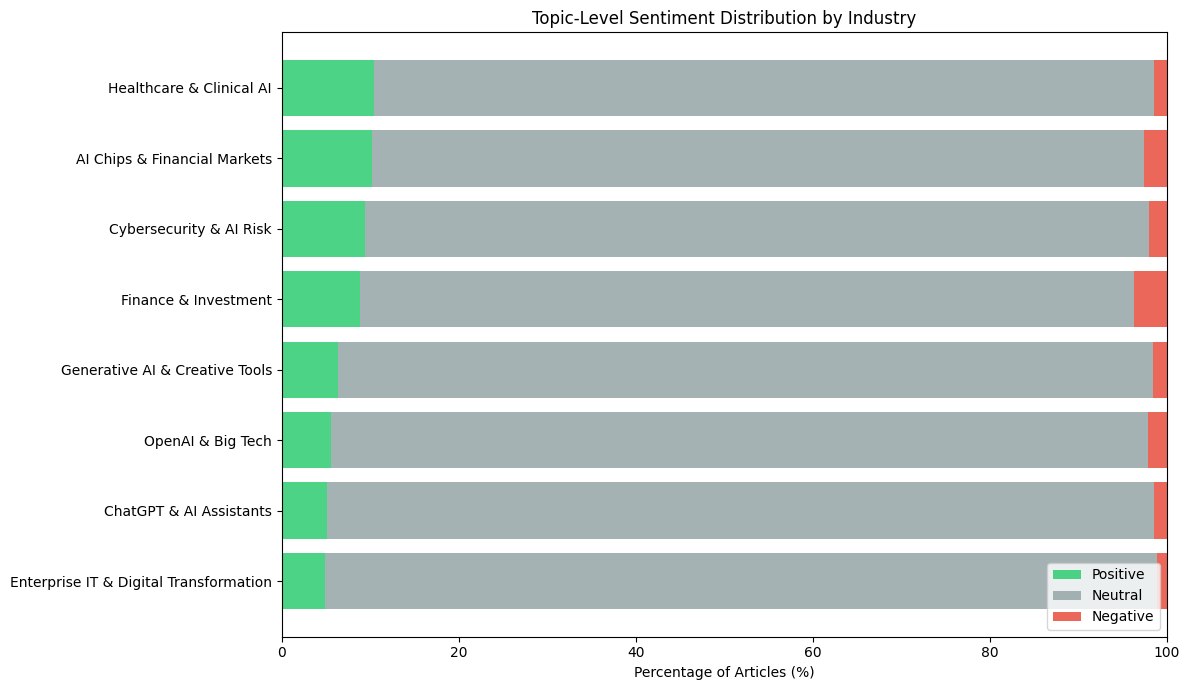


Top 40 organizations after cleaning:
organization
['Nasdaq']                                 108
['Google', 'Google']                        17
['Apple', 'Apple']                          10
['Microsoft', 'Microsoft']                   8
['Artificial Intelligence (AI']              6
['Business Insider']                         6
['OpenAI']                                   5
['RSS Newsletters Newsletter']               5
['Entrepreneur Starting']                    5
['Microsoft', 'Microsoft', 'Microsoft']      5
['Samsung', 'Samsung']                       5
['Intel', 'Nasdaq', 'Intel']                 4
['Space & AI']                               4
['XR', 'IBM']                                4
['Nvidia', 'Nvidia']                         4
['IBM']                                      4
['Privacy Policy']                           4
['Microsoft', 'Nasdaq', 'Microsoft']         4
['NYSE', 'NYSE']                             3
['IBM', 'IBM']                               3
['Lunit A

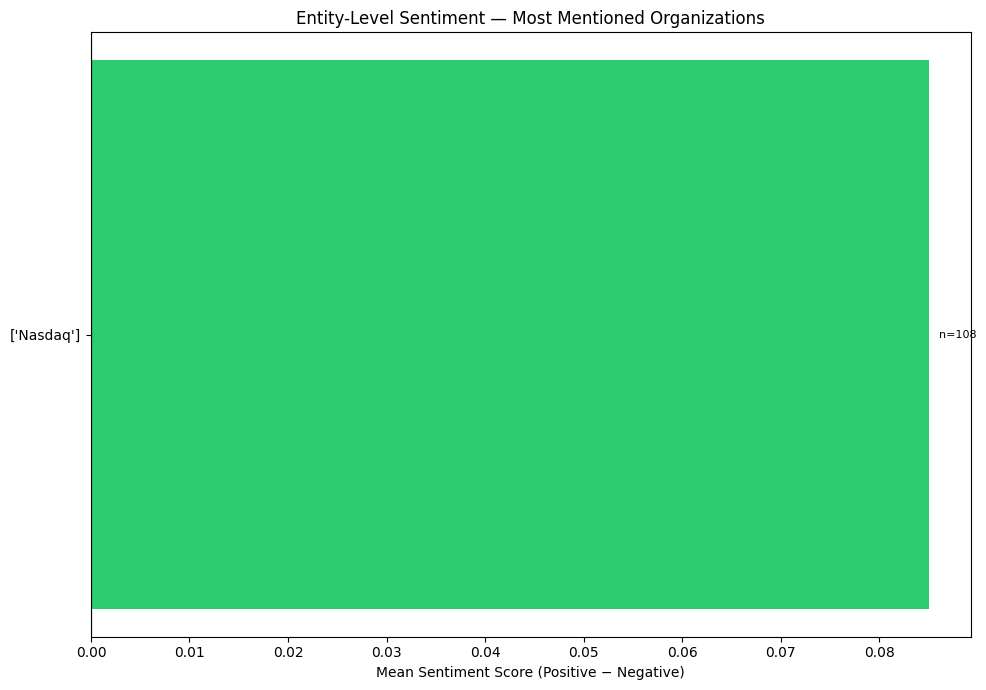

In [10]:
# ── CELL 6: Filter noise before aggregating ───────────────────
import re
import numpy as np
import matplotlib.pyplot as plt

NOISE_INDUSTRIES = {"Outlier / Unclustered", "Other / Mixed"}
df_use = df_merged[~df_merged["industry"].isin(NOISE_INDUSTRIES)].copy()
print(f"Articles after removing noise industries: {len(df_use)}")

# Explicit blocklist for known junk that slips through
JUNK_ORGS = {
    "TextShare", "GMT", "COOUpdate", "Region American Europe Arab World",
    "AutomotivePro BizDevUpdate BusinessCommunicationTrends",
    "GadgetsThe Latest Technology", "WebCatalog Desktop",
    "Mobile Service Digital Media Awards", "Financial Services",
    "Android", "Healthcare", "Invest", "CNA", "WPXI", "NBC",
    "BT Bazaar India", "InvestorPlace", "Artificial Intelligence (AI",
    "TechRadar", "TechCrunch",  # media outlets, not companies being analyzed
    "Various Industries", "Android Central", "Android Central Skip",
    "Menu Search", "Today Headline", "CoverageWho",
}

def is_valid_org(name):
    n = str(name).strip()

    # Explicit blocklist
    if n in JUNK_ORGS:
        return False

    # Too short or too long
    if len(n) < 3 or len(n.split()) > 4:
        return False

    # URLs and web artifacts
    if re.search(r"http|www\.|\.com|\.net|\.org|\.co", n.lower()):
        return False

    # Non-ASCII characters (foreign language text)
    if re.search(r"[^\x00-\x7F]", n):
        return False

    # Navigation / UI artifacts
    if re.search(
        r"\b(news|subscribe|cookie|navigation|photo|search|menu|skip|"
        r"headline|coverage|update|digital|media|awards|latest|technology|"
        r"services|industries|healthcare|invest|region|world|desktop|bazaar)\b",
        n.lower()
    ):
        return False

    # Strings that are clearly concatenated nav items (contain 3+ capitalized words run together)
    if re.search(r"[a-z][A-Z][a-z]", n):  # camelCase artifacts like "BizDevUpdate"
        return False

    return True


# ── CELL 7: Topic-level sentiment ─────────────────────────────
topic_sentiment = (
    df_use.groupby("industry")
    .agg(
        article_count=("sentiment_compound", "count"),
        mean_compound=("sentiment_compound", "mean"),
        pct_positive=("sentiment", lambda x: (x == "positive").mean() * 100),
        pct_neutral=("sentiment", lambda x: (x == "neutral").mean() * 100),
        pct_negative=("sentiment", lambda x: (x == "negative").mean() * 100),
    )
    .reset_index()
    .sort_values("mean_compound", ascending=False)
)

print(topic_sentiment.to_string(index=False))

# Stacked bar chart
topic_pivot = topic_sentiment.set_index("industry")[["pct_positive", "pct_neutral", "pct_negative"]]
topic_pivot = topic_pivot.sort_values("pct_positive", ascending=True)

fig, ax = plt.subplots(figsize=(12, 7))
left = np.zeros(len(topic_pivot))
for col, color, label in zip(
    ["pct_positive", "pct_neutral", "pct_negative"],
    ["#2ecc71", "#95a5a6", "#e74c3c"],
    ["Positive", "Neutral", "Negative"]
):
    ax.barh(topic_pivot.index, topic_pivot[col], left=left, color=color, label=label, alpha=0.85)
    left += topic_pivot[col].values

ax.set_xlabel("Percentage of Articles (%)")
ax.set_title("Topic-Level Sentiment Distribution by Industry")
ax.legend(loc="lower right")
ax.set_xlim(0, 100)
plt.tight_layout()
plt.savefig(BASE + "topic_sentiment_stacked.png", dpi=150)
plt.show()


# ── CELL 8: Entity-level sentiment (orgs) ─────────────────────

# Step 1: explode and clean
org_long = (
    df_use[["orgs", "sentiment", "sentiment_compound", "industry"]]
    .explode("orgs")
    .rename(columns={"orgs": "organization"})
)
org_long = org_long[org_long["organization"].apply(is_valid_org)]

# Step 2: print raw mention counts to verify cleanup worked
org_counts = org_long["organization"].value_counts()
print("\nTop 40 organizations after cleaning:")
print(org_counts.head(40).to_string())

# Step 3: filter to orgs with 50+ mentions
MIN_MENTIONS = 50
top_orgs = org_counts[org_counts >= MIN_MENTIONS].index
org_long_filtered = org_long[org_long["organization"].isin(top_orgs)]
print(f"\nOrgs with {MIN_MENTIONS}+ mentions: {len(top_orgs)}")

# Step 4: aggregate sentiment per org
org_summary = (
    org_long_filtered.groupby("organization")
    .agg(
        mention_count=("sentiment_compound", "count"),
        mean_sentiment=("sentiment_compound", "mean"),
        pct_positive=("sentiment", lambda x: (x == "positive").mean() * 100),
        pct_negative=("sentiment", lambda x: (x == "negative").mean() * 100),
        pct_neutral=("sentiment", lambda x: (x == "neutral").mean() * 100),
    )
    .reset_index()
    .sort_values("mean_sentiment", ascending=False)
)

print("\nOrg sentiment summary:")
print(org_summary.to_string(index=False))
org_summary.to_csv(BASE + "org_sentiment_summary.csv", index=False)

# Step 5: plot top 15 by mention count
plot_orgs = (
    org_summary.sort_values("mention_count", ascending=False)
    .head(15)
    .sort_values("mean_sentiment")
)

fig, ax = plt.subplots(figsize=(10, 7))
colors = ["#e74c3c" if x < 0 else "#2ecc71" for x in plot_orgs["mean_sentiment"]]
bars = ax.barh(plot_orgs["organization"], plot_orgs["mean_sentiment"], color=colors)
ax.axvline(0, color="black", linewidth=0.8)

for bar, count in zip(bars, plot_orgs["mention_count"]):
    ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height() / 2,
            f"n={count}", va="center", fontsize=8)

ax.set_xlabel("Mean Sentiment Score (Positive − Negative)")
ax.set_title("Entity-Level Sentiment — Most Mentioned Organizations")
plt.tight_layout()
plt.savefig(BASE + "entity_sentiment_orgs.png", dpi=150)
plt.show()


In [ ]:

# ── CELL 9: Sentiment over time (uses full 196K df) ───────────
df["date"] = pd.to_datetime(df["date"], errors="coerce")
df_time = df.dropna(subset=["date", "sentiment_compound"]).copy()
df_time["year_month"] = df_time["date"].dt.to_period("M")

time_ts = (
    df_time.groupby("year_month")["sentiment_compound"]
    .mean()
    .reset_index()
)
time_ts["year_month_dt"] = time_ts["year_month"].dt.to_timestamp()

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(time_ts["year_month_dt"], time_ts["sentiment_compound"],
        color="#2980b9", linewidth=2)
ax.axhline(0, color="black", linewidth=0.5, linestyle="--")
ax.fill_between(time_ts["year_month_dt"], time_ts["sentiment_compound"], 0,
                where=time_ts["sentiment_compound"] > 0, alpha=0.2, color="#2ecc71")
ax.fill_between(time_ts["year_month_dt"], time_ts["sentiment_compound"], 0,
                where=time_ts["sentiment_compound"] < 0, alpha=0.2, color="#e74c3c")
ax.set_ylabel("Mean Sentiment Compound Score")
ax.set_title("AI News Sentiment Over Time (196K articles)")
plt.tight_layout()
plt.savefig(BASE + "sentiment_over_time.png", dpi=150)
plt.show()